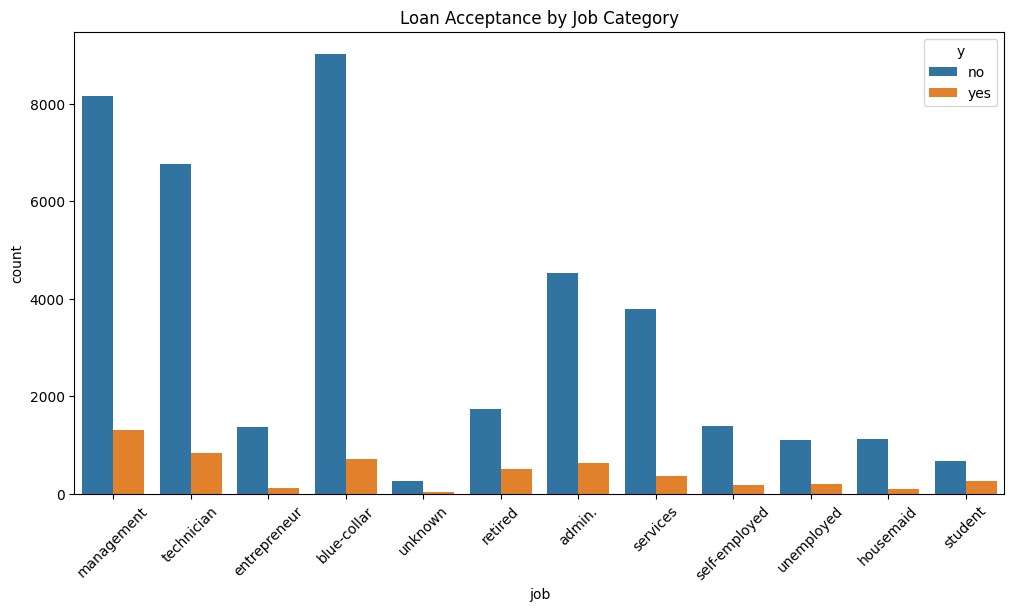

Model Accuracy: 0.90

Classification Report:
               precision    recall  f1-score   support

           0       0.92      0.98      0.95     11977
           1       0.65      0.31      0.42      1586

    accuracy                           0.90     13563
   macro avg       0.78      0.65      0.68     13563
weighted avg       0.88      0.90      0.88     13563



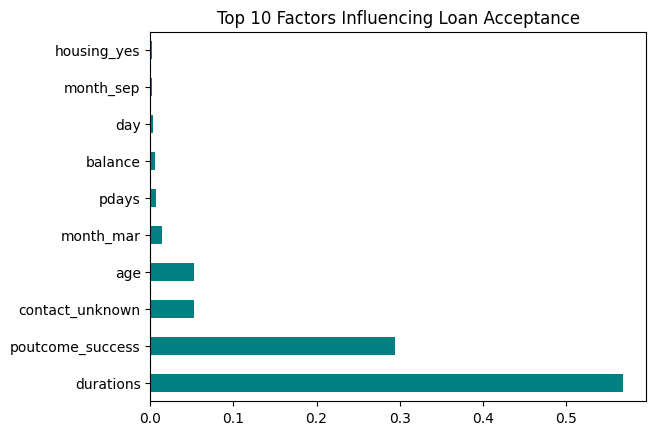

In [8]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, accuracy_score

# 1. Load the dataset with the correct semicolon separator 

df = pd.read_csv('archive/bank-full.csv', sep=';') 

# Clean column names to ensure they match (lowercase and no spaces) 
df.columns = df.columns.str.strip().str.lower()

# 2. Exploratory Data Analysis (EDA)
# Visualizing Loan Acceptance (y) by Job Category [cite: 5]
plt.figure(figsize=(12,6))
sns.countplot(data=df, x='job', hue='y') 
plt.xticks(rotation=45)
plt.title('Loan Acceptance by Job Category')
plt.show()

# 3. Data Preprocessing
# Convert target 'y' (yes/no) to numeric (1/0)
df['y'] = df['y'].map({'yes': 1, 'no': 0})

# Encode categorical features (job, marital, etc.) into numeric dummy variables
X = pd.get_dummies(df.drop('y', axis=1), drop_first=True)
y = df['y']

# 4. Model Training
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Decision Tree allows for clear business insight extraction
dt_model = DecisionTreeClassifier(max_depth=5, random_state=42)
dt_model.fit(X_train, y_train)

# 5. Evaluation & Insights
y_pred = dt_model.predict(X_test)
print(f"Model Accuracy: {accuracy_score(y_test, y_pred):.2f}")
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# Identify which features (e.g., age, balance) most impact the decision
importances = pd.Series(dt_model.feature_importances_, index=X.columns)
importances.nlargest(10).plot(kind='barh', color='teal')
plt.title('Top 10 Factors Influencing Loan Acceptance')
plt.show()